## cloud를 classification해 보자

In [1]:
import numpy as np
import tensorflow as tf
import random as python_random
import os

SEED = 42

np.random.seed(SEED)
python_random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CUDNN_USE_FRONTEND '] = '1'

tf.__version__

2023-09-04 19:49:22.919994: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-09-04 19:49:22.992632: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-04 19:49:24.018532: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


'2.12.0'

In [2]:
origin_dataset_folder = "/app/datasets/UsedDataset/swimcat/"

### DA :  rotation (90,180,270)

In [ ]:
from PIL import Image


img = Image.open("/app/datasets/UsedDataset/swimcat/B-pattern/B_10img.png")
angle = 0

for i in range(4):
    #read the image
    img = img.rotate(angle)
    img.show()
    angle += 90

In [ ]:
import fnmatch
import numpy as np
from PIL import Image
import os 


ts = ['mmml', 'seg']

#폴더 만들기
for t in ts:
    os.makedirs(f'./{t}/origin/Image', exist_ok=True)
    os.makedirs(f'./{t}/origin/Mask', exist_ok=True)

#label에서 해당 시간대 리스트 뽑기
for f in os.listdir('./SegmentationClass/'):
    print(f)
    f= f.rstrip('.png')
    
#     shutil.copy(os.path.join('./SegmentationClass/', f'{f}.png'), os.path.join(f'./test/Mask', f'{f}.png'))
#     shutil.copy(os.path.join('./JPEGImages/', f'{f}.jpg'), os.path.join(f'./test/Image', f'{f}.png'))
    
    img_lbl = Image.open(os.path.join('./SegmentationClass/', f'{f}.png'))
    img_ori = Image.open(os.path.join('./JPEGImages/', f'{f}.jpg'))
    
    img_lbl.save(os.path.join(f'./{ts[0]}/origin/Mask', f'{f}.png'))
    img_ori.save(os.path.join(f'./{ts[0]}/origin/Image', f'{f}.png'))
    
    
    angle = 90
    for i in range(1,4):
        img_lbl.rotate(angle).save(os.path.join(f'./{ts[1]}/origin/Mask', f'{f}_{i}.png'))
        img_ori.rotate(angle).save(os.path.join(f'./{ts[1]}/origin/Image', f'{f}_{i}.png'))
        angle += 90
    

In [ ]:
import os 

dataset_folder = "/app/datasets/UsedDataset/swimcat_da_split/"


for folder in os.listdir(origin_dataset_folder):
    if folder == '.ipynb_checkpoints':
        continue
        
        
    os.makedirs(os.path.join(dataset_folder,folder), exist_ok=True)
        
        
    for f in os.listdir(os.path.join(origin_dataset_folder,folder)):
        f= f[:-4]
        print(f)

        img = Image.open(os.path.join(origin_dataset_folder,folder, f'{f}.png'))

        img.save(os.path.join(dataset_folder,folder, f'{f}.png'))


        angle = 90
        for i in range(1,4):
            img.rotate(angle).save(os.path.join(dataset_folder,folder, f'{f}_{i}.png'))
            
            img.show()
            angle += 90
    
    

### train, test, val 나누기

In [ ]:
import splitfolders
import os


#ratio : train, val, test
splitfolders.ratio(dataset_folder, output=dataset_folder, seed = SEED, ratio=(0.7,0.1,0.2))

### 손으로 기존 class 폴더 지워줌..ㅎㅎ

### CNN으로 classification 구현하기
- https://www.tensorflow.org/tutorials/images/classification?hl=ko

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [6]:
batch_size = 1
img_height, img_width = 125, 125
dataset_folder = "/app/datasets/UsedDataset/swimcat_da_split/"

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(dataset_folder,'train'),
  seed=SEED,
  image_size=(img_height, img_width),
  batch_size=batch_size)

train_ds.class_names

Found 2193 files belonging to 5 classes.


2023-09-04 19:49:57.479446: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


['A-sky', 'B-pattern', 'C-thick-dark', 'D-thick-white', 'E-veil']

In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(dataset_folder,'val'),
  seed=SEED,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds.class_names

Found 312 files belonging to 5 classes.


['A-sky', 'B-pattern', 'C-thick-dark', 'D-thick-white', 'E-veil']

In [9]:
num_classes = len(train_ds.class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 125, 125, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 125, 125, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 62, 62, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 62, 62, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 31, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 31, 31, 64)        1

In [12]:
import numpy as np
import datetime
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint



epochs=500

now = datetime.datetime.now()
log_folder = os.path.join("/app/datasets/UsedDataset/swimcat_da_split_log/",  now.strftime('%Y%m%d_%H%M%S.%f'))


os.makedirs(log_folder, exist_ok=True)

es = EarlyStopping(monitor='val_loss', patience=10)
best_check = ModelCheckpoint(filepath=f"{log_folder}/best_model.h5", 
                             monitor="val_loss",
                             save_best_only=True,
                             save_weights_only=False,
                            )

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs, 
  verbose =1, callbacks=[es, best_check]
)

Epoch 1/500


2023-09-04 19:50:03.827460: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2193]
	 [[{{node Placeholder/_4}}]]
2023-09-04 19:50:03.827900: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [2193]
	 [[{{node Placeholder/_0}}]]


2192/2193 [============================>.] - ETA: 0s - loss: 0.8226 - accuracy: 0.6569

2023-09-04 19:50:39.317985: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [312]
	 [[{{node Placeholder/_4}}]]
2023-09-04 19:50:39.318427: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [312]
	 [[{{node Placeholder/_4}}]]


2193/2193 [==============================] - 38s 16ms/step - loss: 0.8228 - accuracy: 0.6566 - val_loss: 0.6022 - val_accuracy: 0.7115
Epoch 2/500
2193/2193 [==============================] - 35s 16ms/step - loss: 0.6253 - accuracy: 0.7310 - val_loss: 0.5846 - val_accuracy: 0.7436
Epoch 3/500
2193/2193 [==============================] - 35s 16ms/step - loss: 0.4967 - accuracy: 0.7834 - val_loss: 0.4982 - val_accuracy: 0.7981
Epoch 4/500
2193/2193 [==============================] - 35s 16ms/step - loss: 0.4362 - accuracy: 0.8149 - val_loss: 0.4577 - val_accuracy: 0.8269
Epoch 5/500
2193/2193 [==============================] - 35s 16ms/step - loss: 0.4214 - accuracy: 0.8664 - val_loss: 1.8838 - val_accuracy: 0.3462
Epoch 6/500
2193/2193 [==============================] - 36s 16ms/step - loss: 0.5506 - accuracy: 0.7729 - val_loss: 0.3550 - val_accuracy: 0.8526
Epoch 7/500
2193/2193 [==============================] - 37s 17ms/step - loss: 0.4120 - accuracy: 0.8317 - val_loss: 0.3541 - val_

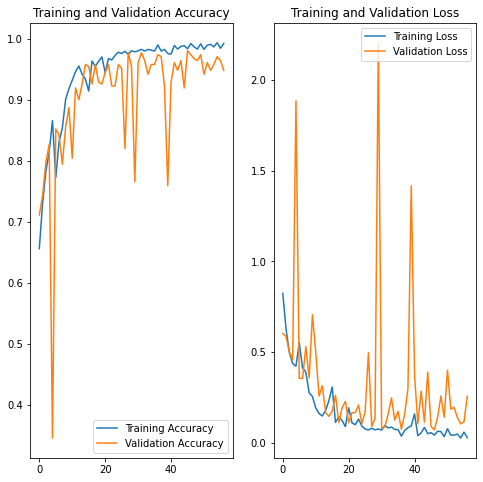

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [14]:
# img = tf.keras.utils.load_img(
#     os.path.join(dataset_folder,'test'), target_size=(img_height, img_width)
# )
# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0) # Create a batch

# predictions = model.predict(img_array)
# score = tf.nn.softmax(predictions[0])

# print(
#     "This image most likely belongs to {} with a {:.2f} percent confidence."
#     .format(class_names[np.argmax(score)], 100 * np.max(score))
# )

In [16]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings(action='ignore')


trues = []
preds = []

for folder_i, folder in enumerate(os.listdir(os.path.join(dataset_folder,'test'))):
    if folder == '.ipynb_checkpoints':
        continue
    
    for f in os.listdir(os.path.join(dataset_folder,'test',folder)):
        img = tf.keras.utils.load_img(os.path.join(dataset_folder,'test',folder,f), target_size=(img_height, img_width))
        
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) # Create a batch

        predictions = model.predict(img_array)
        score = tf.nn.softmax(predictions[0])
        
        class_pred = tf.math.argmax(score)
        preds.append(class_pred.numpy())
        trues.append(folder_i)
        
report = classification_report(trues, preds, target_names=train_ds.class_names)

1/1 [==============================] - 0s 44ms/step


2023-09-05 01:38:32.702071: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:38:32.702503: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:38:32.812331: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float

1/1 [==============================] - 0s 42ms/step


2023-09-05 01:38:32.920128: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:38:32.920503: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:38:33.012362: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float

1/1 [==============================] - 0s 42ms/step


...

2023-09-05 01:39:29.881195: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:39:29.881544: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:39:29.972561: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float

1/1 [==============================] - 0s 39ms/step


2023-09-05 01:39:30.168860: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:39:30.169184: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:39:30.266698: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float

1/1 [==============================] - 0s 38ms/step


2023-09-05 01:39:30.460613: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:39:30.460933: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1,125,125,3]
	 [[{{node Placeholder/_10}}]]
2023-09-05 01:39:30.558412: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float

In [17]:
print(report)

               precision    recall  f1-score   support

        A-sky       1.00      0.96      0.98       180
    B-pattern       0.92      0.99      0.95        72
 C-thick-dark       0.99      1.00      1.00       202
D-thick-white       0.96      0.93      0.94       108
       E-veil       0.85      0.91      0.88        69

     accuracy                           0.96       631
    macro avg       0.95      0.96      0.95       631
 weighted avg       0.97      0.96      0.96       631



In [20]:
import yaml

with open(os.path.join(log_folder, 'result.yaml'), 'w') as f:
    yaml.safe_dump(report, f, default_flow_style=False)